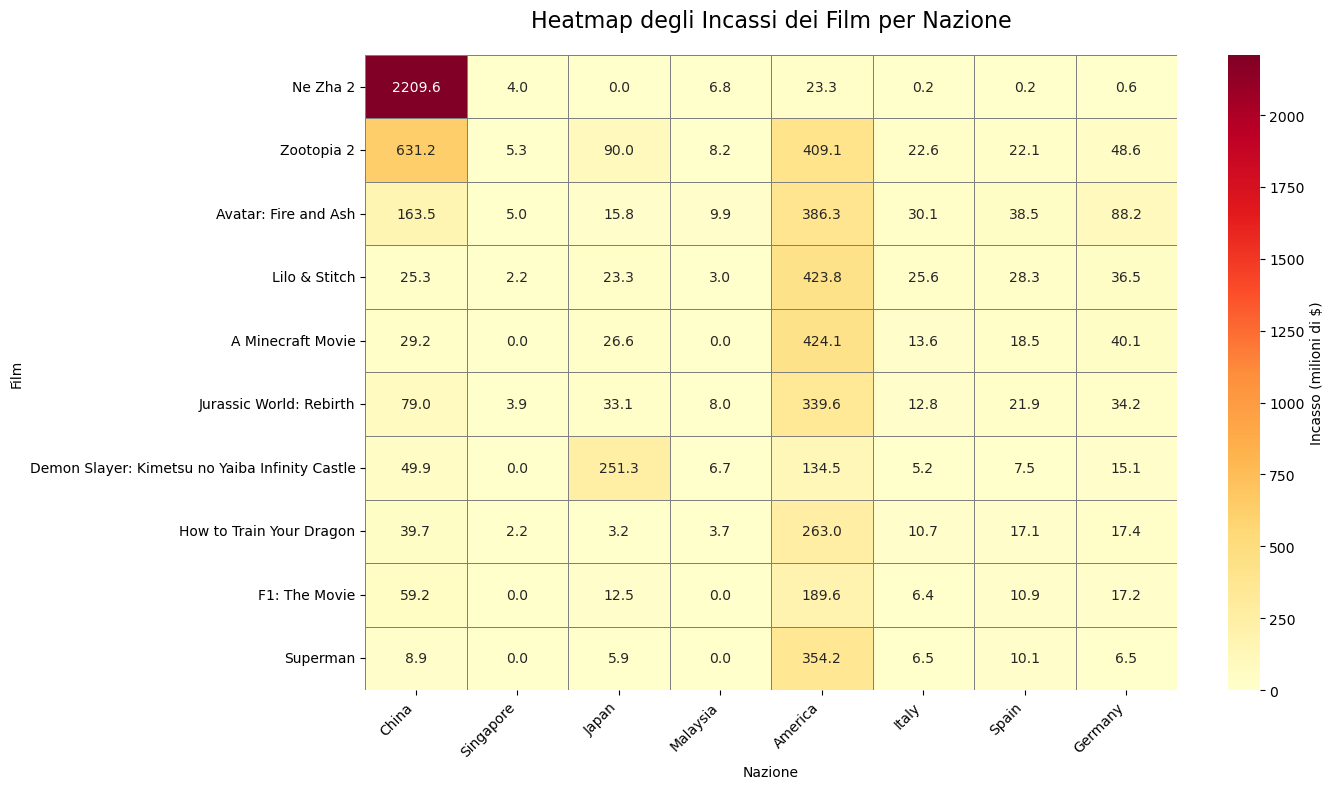

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carica i dati - salta la riga dei continenti
df = pd.read_csv('Nazione - Foglio1 (1).csv', skiprows=1)

# Imposta i nomi dei film come indice
df = df.set_index('Nome film')

# Funzione per convertire i valori
def convert_value(x):
    if x == '-':
        return 0
    elif isinstance(x, str):
        # Rimuovi $ e virgole, poi converti in float
        return float(x.replace('$', '').replace(',', ''))
    else:
        return float(x)

# Converti tutte le colonne usando map (invece di applymap)
df_numeric = df.map(convert_value)

# Crea la heatmap (converti in milioni per leggibilità)
plt.figure(figsize=(14, 8))

sns.heatmap(df_numeric / 1000000,  # Divide per 1 milione
            annot=True,            # Mostra i valori nelle celle
            fmt='.1f',             # Formato: 1 decimale
            cmap='YlOrRd',         # Colori giallo-arancio-rosso
            linewidths=0.5,        # Linee sottili tra le celle
            linecolor='gray',      # Colore delle linee
            cbar_kws={'label': 'Incasso (milioni di $)'})  # Legenda colori

plt.title('Heatmap degli Incassi dei Film per Nazione', fontsize=16, pad=20)
plt.xlabel('Nazione')
plt.ylabel('Film')
plt.xticks(rotation=45, ha='right')  # Ruota etichette assi X
plt.tight_layout()
plt.show()